#### Autor: Rainiero Mendoza de Jesus ***6/4/2026***

In [95]:
# Import the libraries

import csv
from pathlib import Path as Path
import matplotlib.pyplot as plt
from datetime import datetime

In [96]:
# We extract the data from the csv file

path = Path('../data/barahona.csv')
lines = path.read_text(encoding='utf-8').splitlines()
reader = csv.reader(lines)
headers_row = next(reader)

In [97]:
# We explore the fields that our csv file has

for index,x in enumerate(headers_row):
    print(index, x)

0 STATION
1 NAME
2 LATITUDE
3 LONGITUDE
4 ELEVATION
5 DATE
6 TAVG
7 TAVG_ATTRIBUTES
8 TMAX
9 TMAX_ATTRIBUTES
10 TMIN
11 TMIN_ATTRIBUTES


In [98]:
# We extract the columns we want

date = headers_row.index('DATE')
tavg = headers_row.index('TAVG')
tmax = headers_row.index('TMAX')
tmin = headers_row.index('TMIN')
station = headers_row.index('STATION')
name = headers_row.index('NAME')

In [99]:
data = []

for i in reader:

    date_current = datetime.strptime(i[date], '%Y-%m-%d')
    year_current = int(date_current.strftime('%Y'))
    
    station_current = i[station]
    tavg_value = i[tavg]
    tmax_value = i[tmax]
    tmin_value = i[tmin]

    if station_current != 'DRM00078482':
        break

    if data:

        last_dict = data[-1]

        if year_current == last_dict['Year']:

            if tavg_value and tavg_value != 'NaN':
                last_dict['ANUAL TAVG LIST'].append(float(tavg_value))

            if tmax_value and tmax_value != 'NaN':
                last_dict['ANUAL TMAX LIST'].append(float(tmax_value))

            if tmin_value and tmin_value != 'NaN':
                last_dict['ANUAL TMIN LIST'].append(float(tmin_value))

        else:

            new_dict = {
                'Year': year_current,
                'ANUAL TAVG LIST': [],
                'ANUAL TMAX LIST': [],
                'ANUAL TMIN LIST': []
            }

            if tavg_value and tavg_value != 'NaN':
                new_dict['ANUAL TAVG LIST'].append(float(tavg_value))

            if tmax_value and tmax_value != 'NaN':
                new_dict['ANUAL TMAX LIST'].append(float(tmax_value))

            if tmin_value and tmin_value != 'NaN':
                new_dict['ANUAL TMIN LIST'].append(float(tmin_value))

            data.append(new_dict)

    else:

        new_dict = {
            'Year': year_current,
            'ANUAL TAVG LIST': [],
            'ANUAL TMAX LIST': [],
            'ANUAL TMIN LIST': []
        }

        if tavg_value and tavg_value != 'NaN':
            new_dict['ANUAL TAVG LIST'].append(float(tavg_value))

        if tmax_value and tmax_value != 'NaN':
            new_dict['ANUAL TMAX LIST'].append(float(tmax_value))

        if tmin_value and tmin_value != 'NaN':
            new_dict['ANUAL TMIN LIST'].append(float(tmin_value))

        data.append(new_dict)

In [100]:
# We verify the structure we created

print(data[:2])

[{'Year': 2000, 'ANUAL TAVG LIST': [81.0, 77.0, 76.0, 80.0, 83.0, 76.0, 78.0, 78.0, 77.0, 78.0, 76.0, 78.0, 75.0, 72.0, 74.0, 75.0, 73.0, 73.0, 76.0, 79.0, 78.0, 73.0, 74.0, 75.0, 77.0, 76.0, 77.0, 76.0, 76.0, 77.0, 77.0, 77.0, 77.0, 78.0, 79.0, 77.0, 80.0, 77.0, 79.0, 78.0, 78.0, 78.0, 78.0, 79.0, 78.0, 78.0, 77.0, 79.0, 78.0, 76.0, 76.0, 75.0, 76.0, 76.0, 77.0, 77.0, 78.0, 78.0, 78.0, 78.0, 77.0, 78.0, 78.0, 79.0, 78.0, 78.0, 78.0, 79.0, 79.0, 78.0, 76.0, 78.0, 79.0, 77.0, 76.0, 77.0, 77.0, 78.0, 79.0, 80.0, 79.0, 79.0, 79.0, 78.0, 79.0, 78.0, 78.0, 80.0, 80.0, 79.0, 78.0, 79.0, 80.0, 79.0, 80.0, 77.0, 78.0, 78.0, 78.0, 79.0, 78.0, 79.0, 79.0, 80.0, 81.0, 81.0, 81.0, 80.0, 81.0, 81.0, 80.0, 78.0, 80.0, 80.0, 81.0, 82.0, 81.0, 81.0, 82.0, 81.0, 77.0, 78.0, 80.0, 81.0, 80.0, 81.0, 81.0, 81.0, 83.0, 81.0, 80.0, 80.0, 81.0, 81.0, 82.0, 83.0, 81.0, 82.0, 83.0, 83.0, 82.0, 82.0, 83.0, 83.0, 82.0, 82.0, 78.0, 83.0, 82.0, 83.0, 83.0, 83.0, 82.0, 83.0, 84.0, 83.0, 83.0, 83.0, 83.0, 84.0, 84.0

In [101]:

data_00_12 = data[0:13:1]
data_13_24 = data[13:26:1]

print(data_00_12[:2])
print(data_13_24[:2])

[{'Year': 2000, 'ANUAL TAVG LIST': [81.0, 77.0, 76.0, 80.0, 83.0, 76.0, 78.0, 78.0, 77.0, 78.0, 76.0, 78.0, 75.0, 72.0, 74.0, 75.0, 73.0, 73.0, 76.0, 79.0, 78.0, 73.0, 74.0, 75.0, 77.0, 76.0, 77.0, 76.0, 76.0, 77.0, 77.0, 77.0, 77.0, 78.0, 79.0, 77.0, 80.0, 77.0, 79.0, 78.0, 78.0, 78.0, 78.0, 79.0, 78.0, 78.0, 77.0, 79.0, 78.0, 76.0, 76.0, 75.0, 76.0, 76.0, 77.0, 77.0, 78.0, 78.0, 78.0, 78.0, 77.0, 78.0, 78.0, 79.0, 78.0, 78.0, 78.0, 79.0, 79.0, 78.0, 76.0, 78.0, 79.0, 77.0, 76.0, 77.0, 77.0, 78.0, 79.0, 80.0, 79.0, 79.0, 79.0, 78.0, 79.0, 78.0, 78.0, 80.0, 80.0, 79.0, 78.0, 79.0, 80.0, 79.0, 80.0, 77.0, 78.0, 78.0, 78.0, 79.0, 78.0, 79.0, 79.0, 80.0, 81.0, 81.0, 81.0, 80.0, 81.0, 81.0, 80.0, 78.0, 80.0, 80.0, 81.0, 82.0, 81.0, 81.0, 82.0, 81.0, 77.0, 78.0, 80.0, 81.0, 80.0, 81.0, 81.0, 81.0, 83.0, 81.0, 80.0, 80.0, 81.0, 81.0, 82.0, 83.0, 81.0, 82.0, 83.0, 83.0, 82.0, 82.0, 83.0, 83.0, 82.0, 82.0, 78.0, 83.0, 82.0, 83.0, 83.0, 83.0, 82.0, 83.0, 84.0, 83.0, 83.0, 83.0, 83.0, 84.0, 84.0

In [102]:
# We create lists where we store the data already processed and ready to graph

years, anual_tmaxs, anual_tmins = [], [], []
anual_tavgs = []

years_parte1, tmaxs_parte1, tmins_parte1 = [], [], []
tavgs_parte1 = []

years_parte2, tmaxs_parte2, tmins_parte2 = [], [], []
tavgs_parte2 = []

In [103]:
# Once the data is grouped, we perform the desired operations

def cambio_lista(value_list, value_years, value_tmax, value_tmin, value_tavg):
    for i in value_list:
        year = i['Year']
        value_years.append(year)

        tmax = i['ANUAL TMAX LIST']
        tmax_len = len(tmax)
        valor_final = sum(tmax)/tmax_len
        value_tmax.append(valor_final)

        tmin = i['ANUAL TMIN LIST']
        tmin_len = len(tmin)
        valor_mins = sum(tmin)/tmin_len
        value_tmin.append(valor_mins)

        tavg = i['ANUAL TAVG LIST']
        tavg_len = len(tavg)
        valor_tavg = sum(tavg)/tavg_len
        value_tavg.append(valor_tavg)

In [104]:
cambio_lista(value_list=data, value_years=years,value_tmax=anual_tmaxs, value_tmin=anual_tmins, value_tavg=anual_tavgs)
cambio_lista(value_list=data_00_12, value_years=years_parte1,value_tmax=tmaxs_parte1, value_tmin=tmins_parte1, value_tavg=tavgs_parte1)
cambio_lista(value_list=data_13_24, value_years=years_parte2,value_tmax=tmaxs_parte2, value_tmin=tmins_parte2, value_tavg=tavgs_parte2)

In [105]:
# Exploramos las listas para verificar 

print(years)
print(anual_tmaxs)
print(anual_tmins)
print(anual_tavgs)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[88.41228070175438, 88.52121212121212, 87.94626865671641, 88.38461538461539, 87.89084507042253, 88.5373665480427, 89.91605839416059, 90.19928825622776, 89.15151515151516, 89.55015197568389, 90.1182108626198, 89.30745341614907, 89.21016949152542, 90.17454545454545, 89.72668810289389, 90.16825396825396, 90.02605863192183, 89.71381578947368, 89.31481481481481, 89.81672025723472, 90.14429530201342, 89.83695652173913, 90.22525597269625, 91.01324503311258, 91.21337579617834]
[72.10526315789474, 71.94848484848485, 72.44179104477612, 73.8, 73.0, 72.40213523131672, 69.85766423357664, 71.92526690391459, 70.83164983164983, 71.05775075987842, 71.47603833865814, 69.82298136645963, 70.63728813559322, 71.82181818181819, 72.11254019292605, 72.76190476190476, 72.31596091205212, 71.4342105263158, 71.78395061728395, 72.73311897106109, 73.31543624161074, 71

In [106]:
print(years_parte1)
print(tmaxs_parte1)
print(tmins_parte1)
print(tavgs_parte1)

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012]
[88.41228070175438, 88.52121212121212, 87.94626865671641, 88.38461538461539, 87.89084507042253, 88.5373665480427, 89.91605839416059, 90.19928825622776, 89.15151515151516, 89.55015197568389, 90.1182108626198, 89.30745341614907, 89.21016949152542]
[72.10526315789474, 71.94848484848485, 72.44179104477612, 73.8, 73.0, 72.40213523131672, 69.85766423357664, 71.92526690391459, 70.83164983164983, 71.05775075987842, 71.47603833865814, 69.82298136645963, 70.63728813559322]
[80.65254237288136, 82.24712643678161, 82.41359773371104, 82.51754385964912, 82.02287581699346, 82.771875, 84.35457063711911, 84.25626740947075, 83.36565096952909, 83.64931506849315, 83.81369863013698, 83.27123287671233, 83.36338797814207]


In [107]:
print(years_parte2)
print(tmaxs_parte2)
print(tmins_parte2)
print(tavgs_parte2)

[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
[90.17454545454545, 89.72668810289389, 90.16825396825396, 90.02605863192183, 89.71381578947368, 89.31481481481481, 89.81672025723472, 90.14429530201342, 89.83695652173913, 90.22525597269625, 91.01324503311258, 91.21337579617834]
[71.82181818181819, 72.11254019292605, 72.76190476190476, 72.31596091205212, 71.4342105263158, 71.78395061728395, 72.73311897106109, 73.31543624161074, 71.90579710144928, 71.79522184300342, 72.66225165562913, 73.10828025477707]
[84.14520547945206, 83.72602739726027, 84.27671232876712, 83.67213114754098, 83.07397260273973, 83.07142857142857, 83.63287671232877, 84.43287671232876, 84.00833333333334, 83.9945205479452, 84.68493150684931, 84.93785310734464]


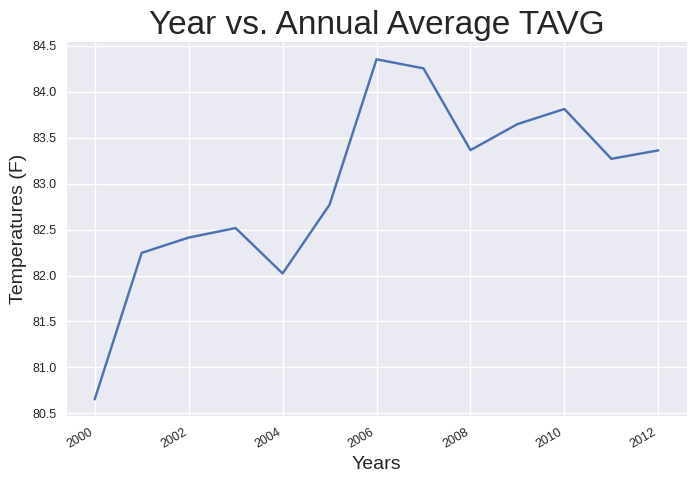

In [108]:
# Make a plot, 2000-2012 Year vs. Annual Average TAVG

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs. Annual Average TAVG"
ax.plot(years_parte1, tavgs_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

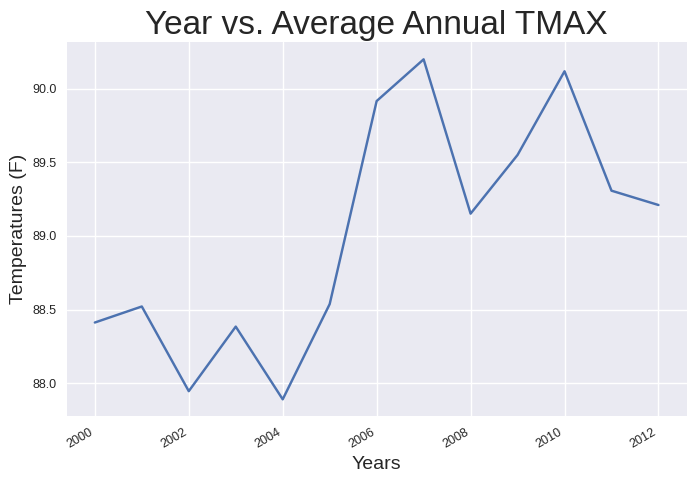

In [109]:
# Make a plots, 2000-2012 Year vs. Average Annual TMAX

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMAX"
fig, ax = plt.subplots()
ax.plot(years_parte1, tmaxs_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

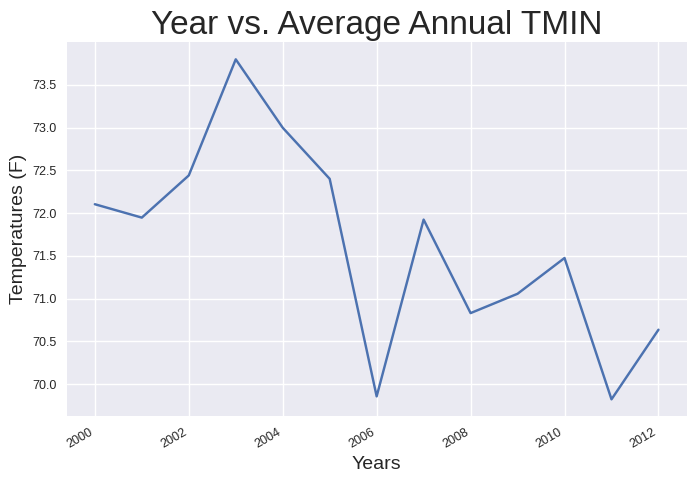

In [110]:
# Make a plot, 2000-2012 Year vs. Average Annual TMIN

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMIN"
fig, ax = plt.subplots()
ax.plot(years_parte1, tmins_parte1)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

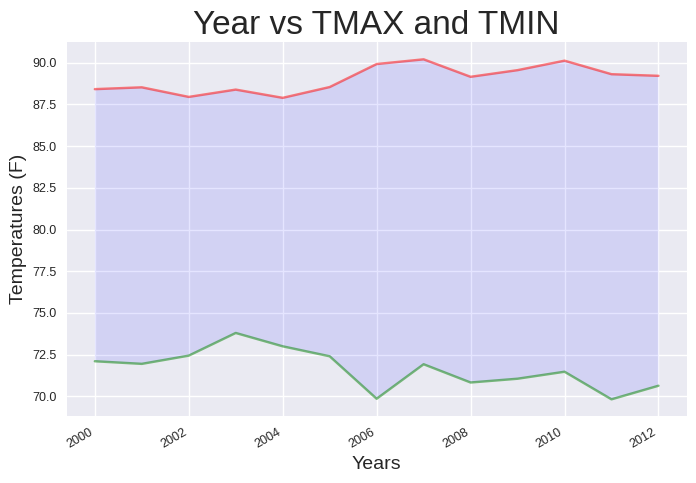

In [111]:
# Make a plot, 2000-2012 Year vs TMAX and TMIN

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs TMAX and TMIN"
ax.plot(years_parte1, tmaxs_parte1, color='red', alpha=0.5)
ax.plot(years_parte1, tmins_parte1, color='green', alpha=0.5)
ax.fill_between(years_parte1, tmaxs_parte1, tmins_parte1, alpha=0.1, facecolor='blue')

ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

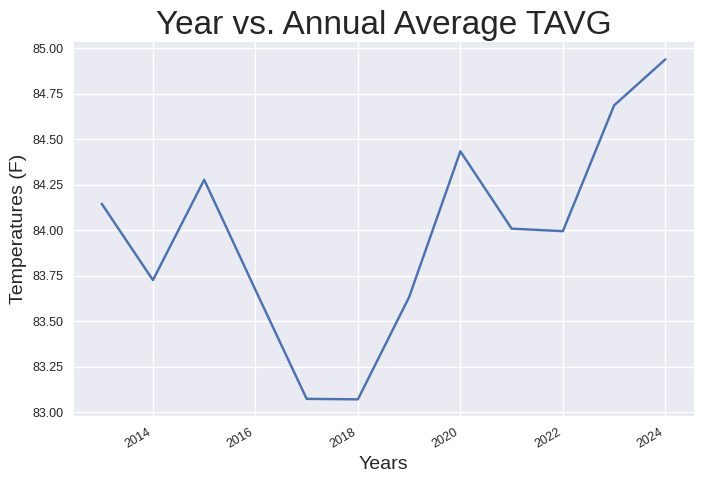

In [112]:
# Make a plot, 2013-2024 Year vs. Annual Average TAVG

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs. Annual Average TAVG"
ax.plot(years_parte2, tavgs_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

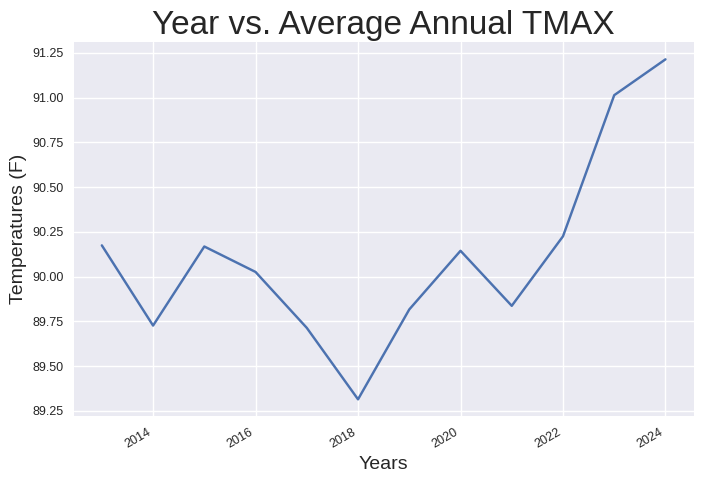

In [113]:
# Make a plots, 2013-2024 Year vs. Average Annual TMAX

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMAX"
fig, ax = plt.subplots()
ax.plot(years_parte2, tmaxs_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

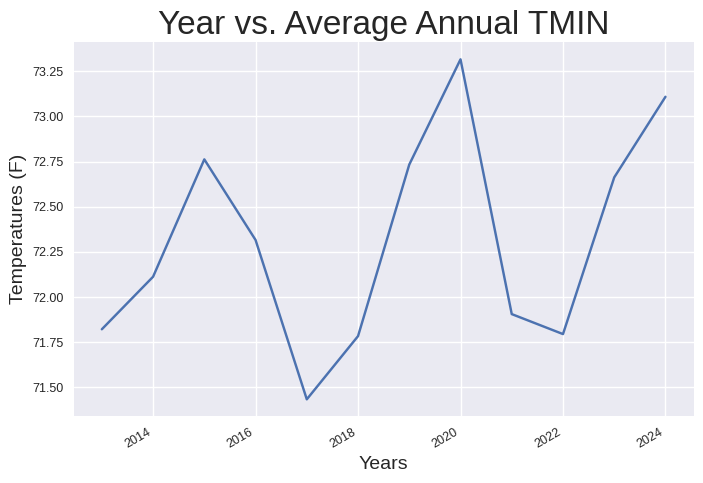

In [114]:
# Make a plot, 2013-2024 Year vs. Average Annual TMIN

plt.style.use('seaborn-v0_8')

title = "Year vs. Average Annual TMIN"
fig, ax = plt.subplots()
ax.plot(years_parte2, tmins_parte2)
ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

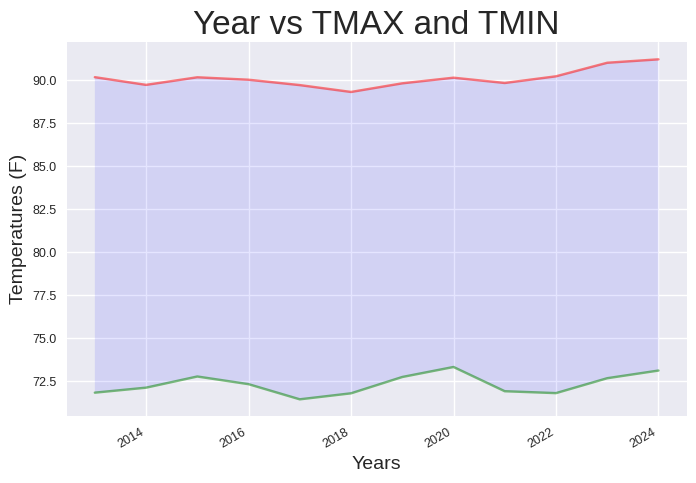

In [115]:
# Make a plot, 2013-2024 Year vs TMAX and TMIN

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()
title = "Year vs TMAX and TMIN"
ax.plot(years_parte2, tmaxs_parte2, color='red', alpha=0.5)
ax.plot(years_parte2, tmins_parte2, color='green', alpha=0.5)
ax.fill_between(years_parte2, tmaxs_parte2, tmins_parte2, alpha=0.1, facecolor='blue')

ax.set_ylabel('Temperatures (F)', fontsize=14)
ax.set_xlabel('Years', fontsize=14)
ax.set_title(title, fontsize=24)
ax.tick_params(labelsize=9)
fig.autofmt_xdate()

plt.show()

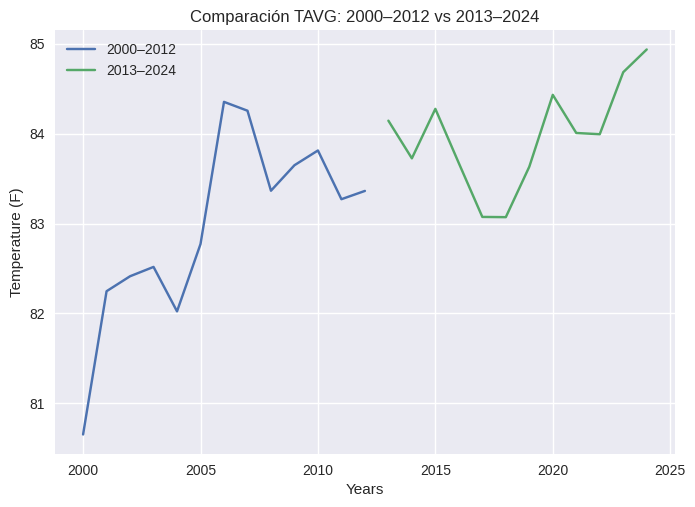

In [120]:
# Comparación TAVG: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tavgs_parte1, label='2000–2012')
ax.plot(years_parte2, tavgs_parte2, label='2013–2024')

ax.set_title('Comparación TAVG: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()

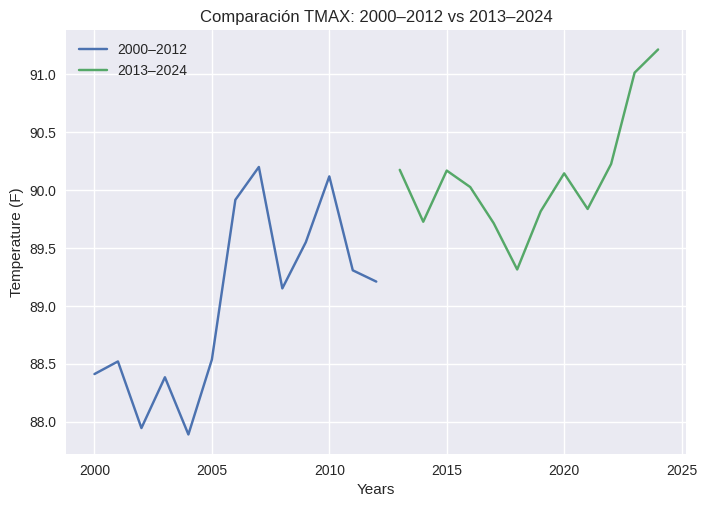

In [121]:
# Comparación TMAX: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tmaxs_parte1, label='2000–2012')
ax.plot(years_parte2, tmaxs_parte2, label='2013–2024')

ax.set_title('Comparación TMAX: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()

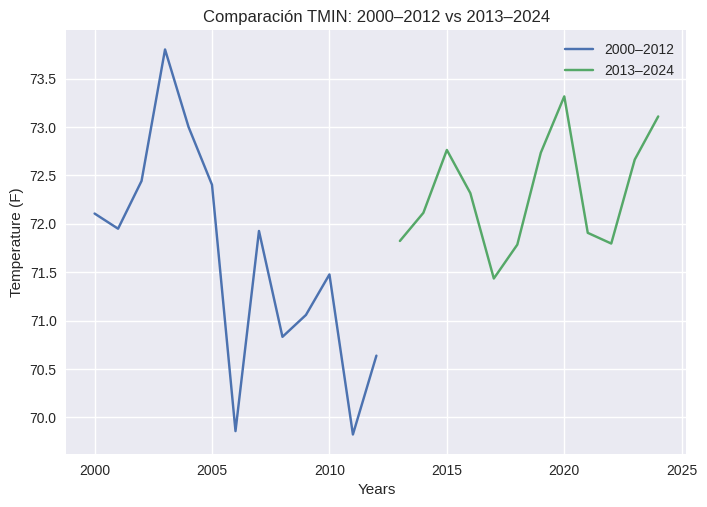

In [122]:
# Comparación TMIN: 2000–2012 vs 2013–2024

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots()

ax.plot(years_parte1, tmins_parte1, label='2000–2012')
ax.plot(years_parte2, tmins_parte2, label='2013–2024')

ax.set_title('Comparación TMIN: 2000–2012 vs 2013–2024')
ax.set_xlabel('Years')
ax.set_ylabel('Temperature (F)')
ax.legend()

plt.show()